## Sample code to run the FL models locally

In [34]:
import torch.nn as nn
import numpy as np
import pandas as pd
from pathlib import Path
from torch.utils.data import DataLoader, TensorDataset

from shared import SimpleNet, eval_local, train_local, get_initial_arrays

In [35]:
site_prefix = "MGL" # "MGL" #OBI #UOT # BHDC

synth_ds_dir = Path("../../../fed_learning/neuroFL/synthetic_ds") # ../../PD-challenge-ds-store/synthetic_ds/ 
features_subdir = synth_ds_dir / site_prefix / 'features'
labels_subdir = synth_ds_dir  / site_prefix / 'labels'

idp_subdir = features_subdir / 'idp'
mri_subdir = features_subdir / 'bids'
tabular_subdir = features_subdir / 'tabular'

demo_save_file = Path(f"{features_subdir}/tabular/demographics.tsv")
labels_save_file = Path(f"{labels_subdir}/labels.tsv")
idp_save_file = Path(f"{features_subdir}/idp/freesurfer-7.3.2.tsv")

In [36]:
# initialize
input_dim = 134
new_arrays = get_initial_arrays(input_dim, dropout=0.0)

# start the training loop
train_performance = []
eval_performance = []
n_rounds = 20
n_epochs = 10

train_config = {
    "data-path": synth_ds_dir / site_prefix,
    "batch-size": 64,
    "epochs": n_epochs,
    "lr": 1e-2,
    "dropout": 0.0
}

test_config = {
    "data-path": synth_ds_dir / site_prefix,
    "batch-size": 1,
    "dropout": 0.0  
}

for round in range(n_rounds):
    print(f"Round {round+1}")
    new_arrays, num_examples, train_metrics = train_local(new_arrays, train_config)
    train_performance.append(train_metrics)

    avg_loss, total, eval_metrics = eval_local(new_arrays, test_config)

    print(f"Evaluation Metrics: {train_metrics}, {eval_metrics}")
    eval_performance.append(eval_metrics)

Round 1
Evaluation Metrics: {'train_loss': 139.412841796875}, {'val_loss': 710.510546875, 'val_accuracy': 0.7}
Round 2
Evaluation Metrics: {'train_loss': 205.9954833984375}, {'val_loss': 449.85537109375, 'val_accuracy': 0.85}
Round 3
Evaluation Metrics: {'train_loss': 475.7506103515625}, {'val_loss': 438.5951171875, 'val_accuracy': 0.85}
Round 4
Evaluation Metrics: {'train_loss': 316.6480712890625}, {'val_loss': 129.46796875, 'val_accuracy': 0.95}
Round 5
Evaluation Metrics: {'train_loss': 13.2705078125}, {'val_loss': 114.126171875, 'val_accuracy': 0.85}
Round 6
Evaluation Metrics: {'train_loss': 438.056396484375}, {'val_loss': 210.14453125, 'val_accuracy': 0.85}
Round 7
Evaluation Metrics: {'train_loss': 317.9893798828125}, {'val_loss': 1017.6744140625, 'val_accuracy': 0.7}
Round 8
Evaluation Metrics: {'train_loss': 143.5850830078125}, {'val_loss': 380.141015625, 'val_accuracy': 0.8}
Round 9
Evaluation Metrics: {'train_loss': 111.02294921875}, {'val_loss': 67.89208984375, 'val_accurac

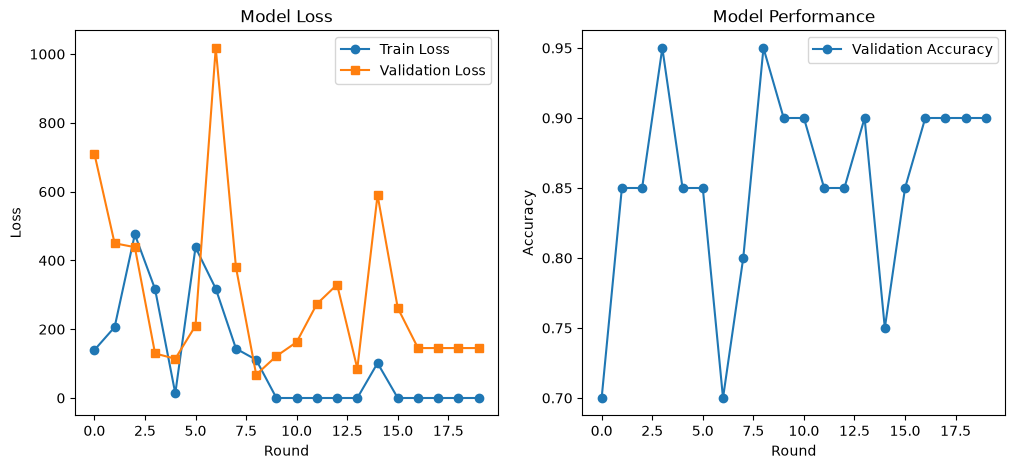

In [37]:
# Plot the evaluation metrics
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# Plot train and validation loss
axes[0].plot([x['train_loss'] for x in train_performance], marker='o', label='Train Loss')
axes[0].plot([x['val_loss'] for x in eval_performance], marker='s', label='Validation Loss')
axes[0].set_title('Model Loss')
axes[0].set_xlabel('Round')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Plot Validation Accuracy
axes[1].plot([x['val_accuracy'] for x in eval_performance], marker='o', label='Validation Accuracy')
axes[1].set_title('Model Performance')
axes[1].set_xlabel('Round')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
plt.show()